# Prediction prototype 

## 1. Setup

In [40]:
%load_ext autoreload
%autoreload 2

import json
import pickle
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sentinel.params import PCA_THRESHOLD, WINDOW_SIZE
from sentinel.ml_logic.data import MODELS_DIR, PROCESSED_DIR
from sentinel.ml_logic.predictor import predict_report
from sentinel.ml_logic.metrics import compute_all_metrics
from sentinel.ml_logic.viz import (
    plot_score_distribution,
    plot_score_timeline,
    plot_score_panels,
    plot_event_zoom_with_score,
    plot_confusion_and_channel_errors,
)

sns.set_theme(style="whitegrid")
print("threshold:", PCA_THRESHOLD, " window:", WINDOW_SIZE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
threshold: 0.060404  window: 100


## 2. Load artefacts

Everything the predictor needs lives in `models/` and `data/processed/`:
the fitted PCA, the RobustScaler, and the list of 58 target channels.

In [32]:
with open(MODELS_DIR / "pca.pkl", "rb") as f:
    pca = pickle.load(f)
with open(MODELS_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(PROCESSED_DIR / "preprocessing_config.json") as f:
    features = json.load(f)["target_channels"]

print("PCA components:", pca.n_components_)
print("scaler fitted on", scaler.n_features_in_, "features")
print("features:", len(features), "channels")

PCA components: 38
scaler fitted on 58 features
features: 58 channels


## 3. Prototype `predict_slice`

`predict_report` from `sentinel.ml_logic.predictor` is the
model-agnostic version of what we want: one reconstruction pass, one dict
with row scores, window scores, per-channel MSE, per-window per-channel
MSE, `n_top_channels`, threshold, and feature names. `predict_slice` is a
three-line local wrapper that fixes the model/scaler/features arguments
so the rest of the notebook can pass just a DataFrame and a threshold.

In [ ]:
def predict_slice(df_raw: pd.DataFrame, threshold: float = PCA_THRESHOLD) -> dict:
    # thin wrapper: fixes (model, scaler, features) so callers just pass a DataFrame
    return predict_report(pca, scaler, features, df_raw,
                          threshold=threshold, win=WINDOW_SIZE)

## 4. Full test_intern prediction

Load the held-out `test_intern_raw.npy` (raw, **unscaled**) and run
`predict_slice` on it. The full 2.19 M-row pass takes ~1 s on the PCA
model. After this, every downstream cell reads from the same `out` dict —
no recomputation.

In [ ]:
X_raw_all = np.load(PROCESSED_DIR / "test_intern_raw.npy")
y_all     = np.load(PROCESSED_DIR / "y_test_intern.npy")
print("X_raw:", X_raw_all.shape, "anomalies:", int(y_all.sum()))

df_test = pd.DataFrame(X_raw_all, columns=features)
df_test["is_anomaly"] = y_all.astype(np.int8)

t0 = time.time()
out = predict_slice(df_test, threshold=PCA_THRESHOLD)
print(f"predict_slice: {time.time() - t0:.2f}s")

expected_keys = {
    "labels", "row_scores", "window_scores",
    "per_channel_mse", "window_channel_mse",
    "n_top_channels", "threshold", "features",
}
assert set(out) == expected_keys
assert out["labels"].shape     == (len(df_test),)
assert out["row_scores"].shape == (len(df_test),)
assert out["per_channel_mse"].shape == (len(features),)
assert out["window_channel_mse"].shape[1] == len(features)

print("rows           :", f"{len(df_test):,}")
print("true anom      :", f"{int(df_test['is_anomaly'].sum()):,}")
print("predicted      :", f"{int(out['labels'].sum()):,}")
print("row-score range:", float(out['row_scores'].min()), '–', float(out['row_scores'].max()))
print("threshold      :", out['threshold'])

## 5. ALL possible metrics

`compute_all_metrics` returns the full panel the bootcamp summary tracks:

- **event_*** — our standard event-wise precision/recall/F (primary
  tuning metric)
- **esa_*** — the Kaggle-leaderboard ESA-corrected variant (TNR-corrected
  precision)
- **pa_*** — point-adjust F1 from the time-series-AD literature (Xu et al.
  2018), for reference
- **row_*** — raw per-row precision / recall / F1 (what the frontend tiles
  show)
- **event_detection_rate**, **tp_events**, **n_events**, **fp_pred_events** —
  jury-friendly "caught X of Y events" numbers

In [35]:
y_true = df_test["is_anomaly"].values
y_pred = out["labels"]

t0 = time.time()
metrics = compute_all_metrics(y_true, y_pred)
print(f"compute_all_metrics: {time.time() - t0:.1f}s")

metric_groups = {
    "event"       : ["event_f05", "event_f1", "event_f2",
                     "event_precision", "event_recall"],
    "ESA (kaggle)": ["esa_f05", "esa_precision", "esa_recall", "esa_tnr"],
    "counts"      : ["event_detection_rate", "tp_events", "n_events",
                     "fp_pred_events"],
    "point-adjust": ["pa_f1", "pa_precision", "pa_recall"],
    "row-level"   : ["row_precision", "row_recall", "row_f1"],
}
rows = [(grp, k, metrics[k]) for grp, keys in metric_groups.items() for k in keys]
pd.DataFrame(rows, columns=["group", "metric", "value"]).set_index(["group", "metric"])

compute_all_metrics: 18.6s


value
group        metric                         
event        event_f05              0.984252
             event_f1               0.961538
             event_f2               0.939850
             event_precision        1.000000
             event_recall           0.925926
ESA (kaggle) esa_f05                0.473550
             esa_precision          0.422006
             esa_recall             0.925926
             esa_tnr                0.422006
counts       event_detection_rate   0.925926
             tp_events             25.000000
             n_events              27.000000
             fp_pred_events         0.000000
point-adjust pa_f1                  0.266651
             pa_precision           0.154591
             pa_recall              0.969222
row-level    row_precision          0.132710
             row_recall             0.811049
             row_f1                 0.228097

## 6. Score distribution

Nominal vs. anomaly score histograms on the full test set. Auto log-x
kicks in because PCA row-scores span ~4 decades (≈1e-3 to ≈30).

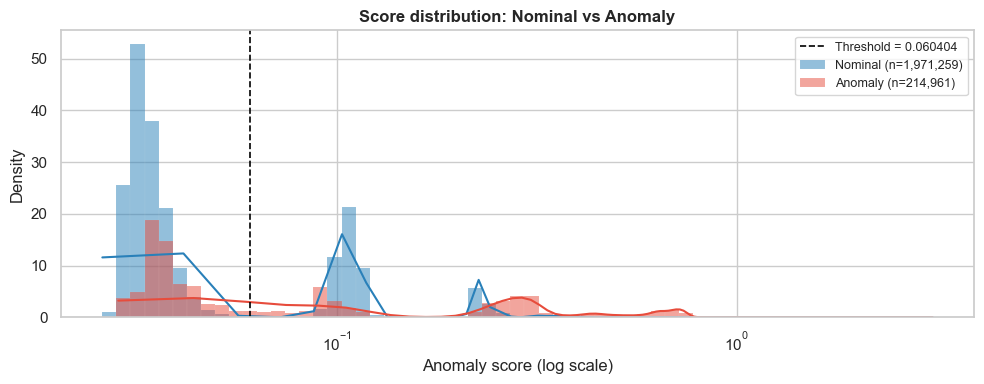

In [36]:
plot_score_distribution(out["row_scores"], y_true, out["threshold"]);

## 7. Score timeline

Two views across the full 2.19 M rows:

1. **Overlay** — reconstruction error with true-anomaly shading and the
   threshold line. 5 % random sampling keeps the plot responsive.
2. **Three-panel** — reconstruction error on top, true-anomaly ribbon in
   the middle, predicted-anomaly ribbon at the bottom, all sharing the
   same x-axis so false positives and missed events are easy to spot.
   Uses `df_test.index` as the row-index axis.

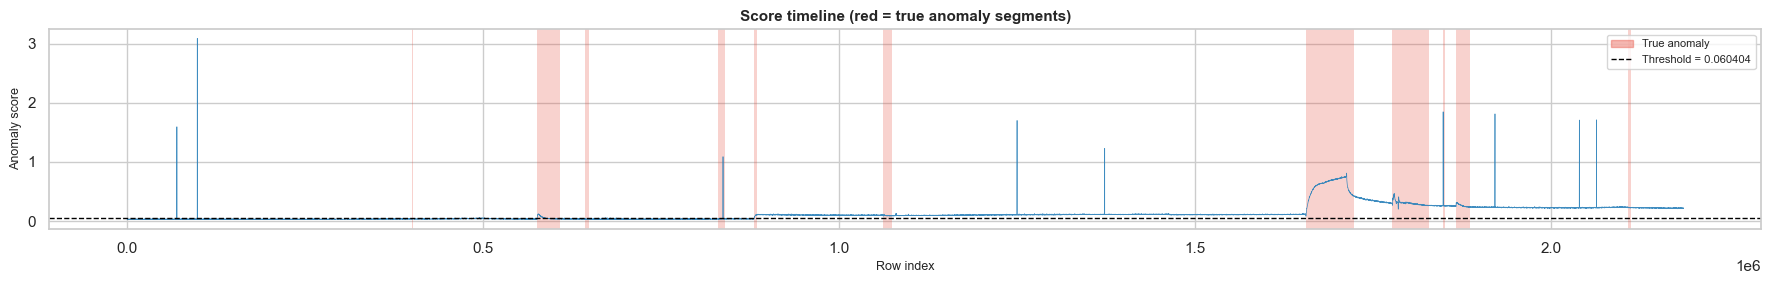

In [37]:
plot_score_timeline(
    out["row_scores"], y_true, out["threshold"],
    sample_frac=0.05,
);

In [ ]:
plot_score_panels(
    scores=out["row_scores"],
    y_true=y_true,
    y_pred=out["labels"],
    threshold=out["threshold"],
    index=df_test.index.values,
    sample_frac=0.05,
);

## 8. Event zoom

Closer look at one anomaly event with clean background: rows
`98,664–98,688` (25 rows, peak row-score ~3.1, background ~0.03). The
channels shown are the top contributors by MSE **inside anomaly windows**,
not the slice-wide mean — that way the ranking reflects what drove the
detection, not what was noisy on average.

top channels (by anomaly-window MSE): ['channel_58', 'channel_60', 'channel_76', 'channel_40']


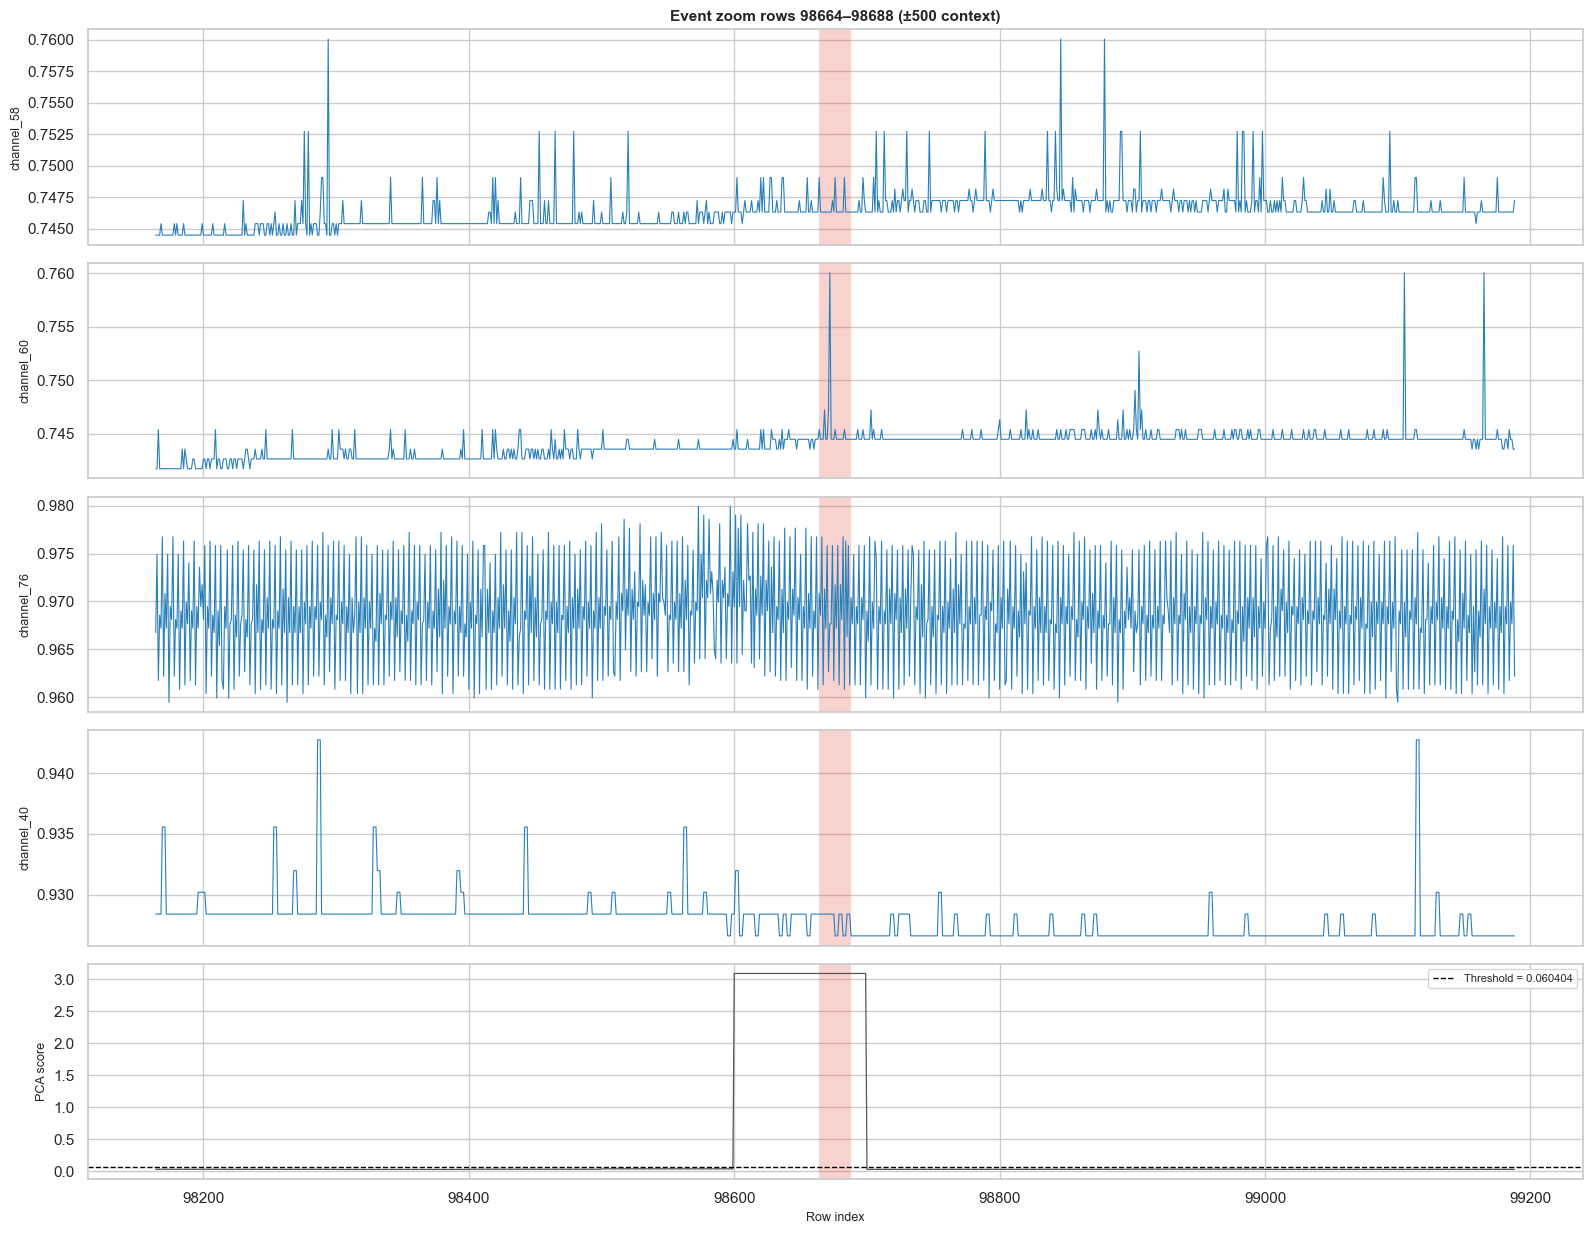

In [38]:
# Rank channels by MSE within the anomaly windows
anom_win_mask = out["window_scores"] > out["threshold"]
if anom_win_mask.any():
    per_ch_anom = out["window_channel_mse"][anom_win_mask].mean(axis=0)
else:
    per_ch_anom = out["per_channel_mse"]

top_channels = [features[i] for i in np.argsort(per_ch_anom)[::-1][:4]]
print("top channels (by anomaly-window MSE):", top_channels)

plot_event_zoom_with_score(
    df_raw=df_test,
    scores=out["row_scores"],
    seg_start=98_664,
    seg_end=98_688,
    channels=top_channels,
    threshold=out["threshold"],
    context=500,
);

## 9. Confusion matrix + top channels

Row-level confusion matrix over the full 2.19 M rows, plus the top-10
channels ranked by MSE inside anomaly windows (same rule as the zoom
above, so the two diagnostics agree on which channels drove detection).

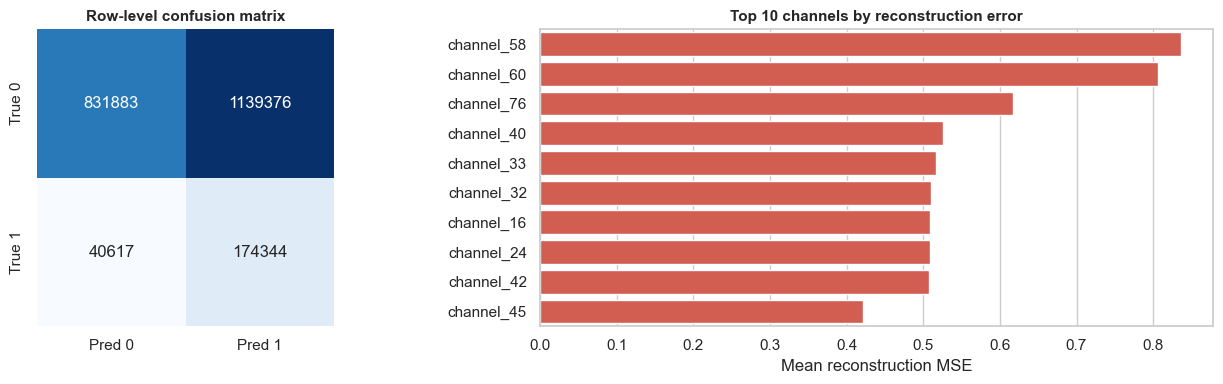

In [39]:
plot_confusion_and_channel_errors(
    y_true=y_true,
    y_pred=y_pred,
    per_channel_mse=per_ch_anom,
    channel_names=features,
    top_k=10,
);